# CS3807 — Deep Learning Laboratory
## Experiment 3 : Implementation of Convolutional Neural Networks (CNNs) for Image Classification

## Task 0 : Setup

In [24]:
!pip install -q scikit-learn==1.5.2 scikeras==0.13.0 kaggle

import os
from google.colab import files

# Upload kaggle.json via the Colab sidebar (Files pane) before running this cell,
# or use the upload dialog below.
if not os.path.exists("kaggle.json"):
    print("Please upload your kaggle.json file:")
    uploaded = files.upload()

os.makedirs("/root/.kaggle", exist_ok=True)
os.system("cp kaggle.json /root/.kaggle/kaggle.json")
os.system("chmod 600 /root/.kaggle/kaggle.json")

!kaggle datasets download -d pankrzysiu/cifar10-python -p /content/data --unzip

Dataset URL: https://www.kaggle.com/datasets/pankrzysiu/cifar10-python
License(s): other
100% 325M/325M [00:05<00:00, 65.9MB/s]



In [25]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import (confusion_matrix, classification_report,
                              precision_score, recall_score, f1_score, accuracy_score)

FIG_DIR = "outputs/figures"
os.makedirs(FIG_DIR, exist_ok=True)

plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman", "DejaVu Serif"]
plt.rcParams["font.size"] = 13
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["axes.titleweight"] = "bold"

def save_fig(fig, name, dpi=110):
    path = os.path.join(FIG_DIR, name)
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved: {path}")

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Locate extracted CIFAR-10 batch files (Kaggle version uses the original
# Python pickle batch format: data_batch_1..5, test_batch)
DATA_DIR = "/content/data"
for root, dirs, fnames in os.walk(DATA_DIR):
    if "data_batch_1" in fnames:
        DATA_DIR = root
        break

def load_batch(file):
    with open(file, "rb") as f:
        d = pickle.load(f, encoding="bytes")
    data = d[b"data"].reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
    labels = np.array(d[b"labels"])
    return data, labels

x_train_list, y_train_list = [], []
for i in range(1, 6):
    xb, yb = load_batch(os.path.join(DATA_DIR, f"data_batch_{i}"))
    x_train_list.append(xb)
    y_train_list.append(yb)

x_train = np.concatenate(x_train_list)
y_train = np.concatenate(y_train_list).reshape(-1, 1)
x_test, y_test = load_batch(os.path.join(DATA_DIR, "test_batch"))
y_test = y_test.reshape(-1, 1)

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape :", x_test.shape)
print("y_test shape :", y_test.shape)
print("Number of classes:", len(np.unique(y_train)))

x_train shape: (50000, 32, 32, 3)
y_train shape: (50000, 1)
x_test shape : (10000, 32, 32, 3)
y_test shape : (10000, 1)
Number of classes: 10


## Task 1 : Load CIFAR-10, Display Samples, Print Dimensions, Plot Class Distribution

/tmp/ipykernel_894/216795387.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ax.set_title(CLASS_NAMES[int(y_train[i])], fontsize=13)


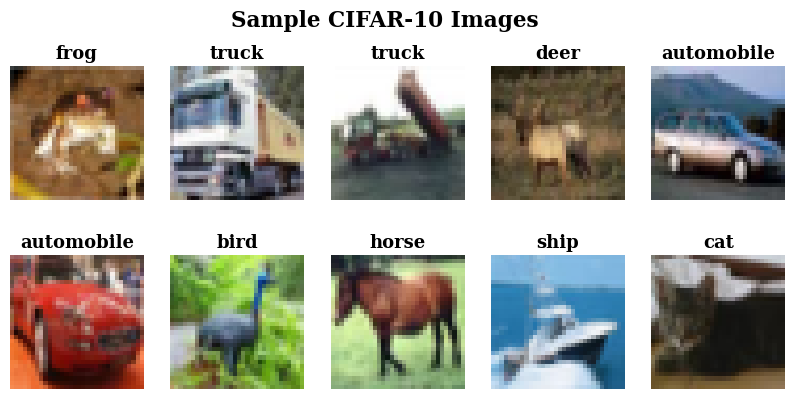

Saved: outputs/figures/01_sample_images.png


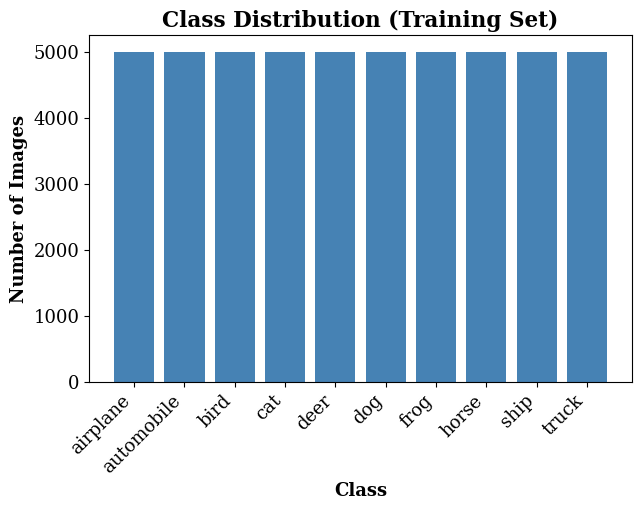

Saved: outputs/figures/02_class_distribution.png


In [26]:
x_train_n = x_train.astype("float32") / 255.0
x_test_n = x_test.astype("float32") / 255.0
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

# Sample images
fig, axes = plt.subplots(2, 5, figsize=(10, 4.5))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i])
    ax.set_title(CLASS_NAMES[int(y_train[i])], fontsize=13)
    ax.axis("off")
fig.suptitle("Sample CIFAR-10 Images", fontweight="bold")
plt.show()
save_fig(fig, "01_sample_images.png")

# Class distribution
unique, counts = np.unique(y_train, return_counts=True)
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar([CLASS_NAMES[u] for u in unique], counts, color="steelblue")
ax.set_xlabel("Class", fontweight="bold")
ax.set_ylabel("Number of Images", fontweight="bold")
ax.set_title("Class Distribution (Training Set)")
plt.xticks(rotation=45, ha="right")
plt.show()
save_fig(fig, "02_class_distribution.png")

## Task 2 : Convolution Layer — Compare Kernel Sizes (3x3, 5x5, 7x7)

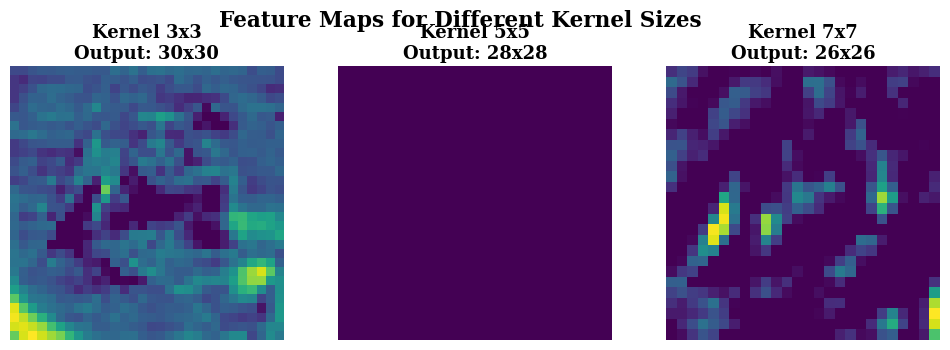

Saved: outputs/figures/03_kernel_size_comparison.png
Feature map sizes for each kernel size (input 32x32, stride=1, padding=valid):
Kernel 3x3 -> Feature map size: (30, 30)
Kernel 5x5 -> Feature map size: (28, 28)
Kernel 7x7 -> Feature map size: (26, 26)


In [27]:
sample_img = np.expand_dims(x_train_n[0], axis=0)

kernel_sizes = [3, 5, 7]
feature_map_sizes = {}

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, k in zip(axes, kernel_sizes):
    conv = layers.Conv2D(filters=1, kernel_size=k, padding="valid", activation="relu")
    out = conv(sample_img)
    feature_map_sizes[k] = out.shape[1:3]
    ax.imshow(out[0, :, :, 0], cmap="viridis")
    ax.set_title(f"Kernel {k}x{k}\nOutput: {out.shape[1]}x{out.shape[2]}", fontsize=13)
    ax.axis("off")

fig.suptitle("Feature Maps for Different Kernel Sizes", fontweight="bold")
plt.show()
save_fig(fig, "03_kernel_size_comparison.png")

print("Feature map sizes for each kernel size (input 32x32, stride=1, padding=valid):")
for k, s in feature_map_sizes.items():
    print(f"Kernel {k}x{k} -> Feature map size: {s}")

## Task 3 : Hyperparameter Study — Stride and Padding

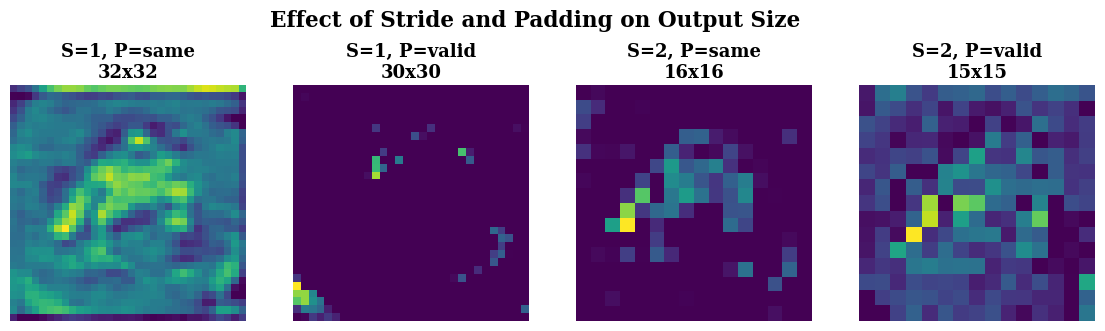

Saved: outputs/figures/04_stride_padding_comparison.png
Stride | Padding | Output Size
     1 | same    | (32, 32)
     1 | valid   | (30, 30)
     2 | same    | (16, 16)
     2 | valid   | (15, 15)


In [28]:
configs = [
    {"stride": 1, "padding": "same"},
    {"stride": 1, "padding": "valid"},
    {"stride": 2, "padding": "same"},
    {"stride": 2, "padding": "valid"},
]

results = []
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, cfg in zip(axes, configs):
    conv = layers.Conv2D(filters=1, kernel_size=3, strides=cfg["stride"],
                          padding=cfg["padding"], activation="relu")
    out = conv(sample_img)
    results.append((cfg["stride"], cfg["padding"], out.shape[1:3]))
    ax.imshow(out[0, :, :, 0], cmap="viridis")
    ax.set_title(f"S={cfg['stride']}, P={cfg['padding']}\n{out.shape[1]}x{out.shape[2]}", fontsize=13)
    ax.axis("off")

fig.suptitle("Effect of Stride and Padding on Output Size", fontweight="bold")
plt.show()
save_fig(fig, "04_stride_padding_comparison.png")

print("Stride | Padding | Output Size")
for s, p, size in results:
    print(f"{s:6d} | {p:7s} | {size}")

## Task 4 : Visualize Feature Maps After First Convolution Layer (at least 8 maps)

Feature map tensor shape: (1, 32, 32, 32)


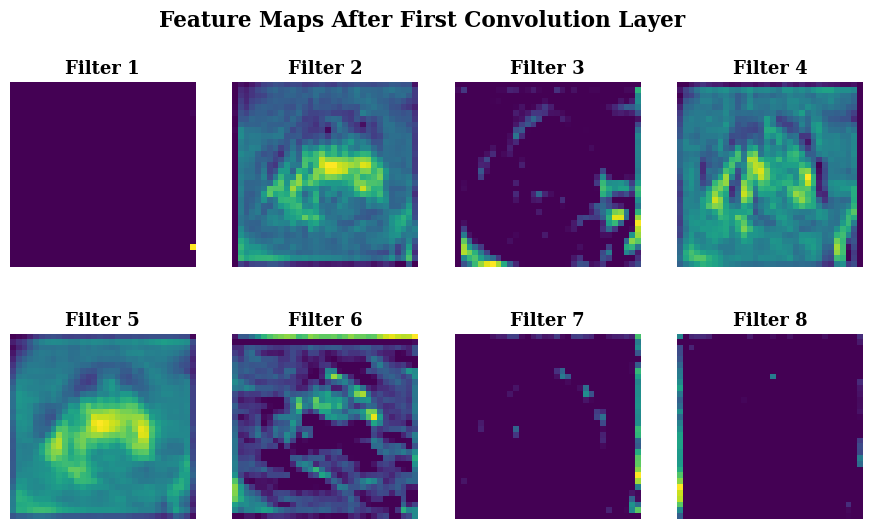

Saved: outputs/figures/05_feature_maps_conv1.png


In [29]:
feat_model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.Conv2D(32, (3, 3), activation="relu", padding="same")
])

feature_maps = feat_model.predict(sample_img, verbose=0)
print("Feature map tensor shape:", feature_maps.shape)

n_maps = 8
fig, axes = plt.subplots(2, 4, figsize=(11, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(feature_maps[0, :, :, i], cmap="viridis")
    ax.set_title(f"Filter {i+1}", fontsize=13)
    ax.axis("off")
fig.suptitle("Feature Maps After First Convolution Layer", fontweight="bold")
plt.show()
save_fig(fig, "05_feature_maps_conv1.png")

## Task 5 : Compare Max Pooling and Average Pooling

Max Pooling output shape: (1, 16, 16, 32)
Average Pooling output shape: (1, 16, 16, 32)


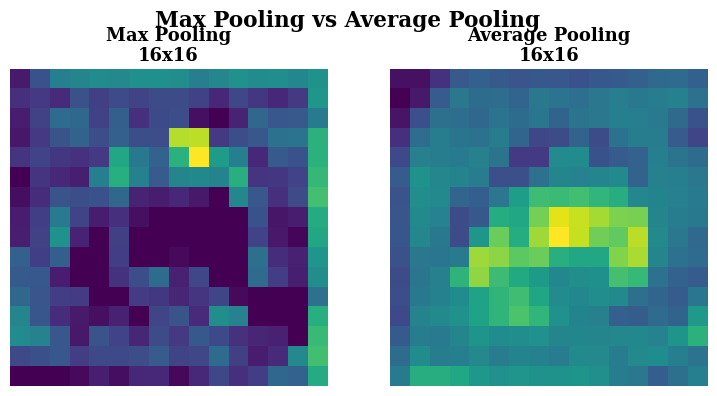

Saved: outputs/figures/06_maxpool_vs_avgpool.png


In [30]:
pool_model_max = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2))
])
pool_model_avg = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.AveragePooling2D((2, 2))
])

max_out = pool_model_max.predict(sample_img, verbose=0)
avg_out = pool_model_avg.predict(sample_img, verbose=0)

print("Max Pooling output shape:", max_out.shape)
print("Average Pooling output shape:", avg_out.shape)

fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
axes[0].imshow(max_out[0, :, :, 0], cmap="viridis")
axes[0].set_title(f"Max Pooling\n{max_out.shape[1]}x{max_out.shape[2]}", fontsize=13)
axes[0].axis("off")
axes[1].imshow(avg_out[0, :, :, 0], cmap="viridis")
axes[1].set_title(f"Average Pooling\n{avg_out.shape[1]}x{avg_out.shape[2]}", fontsize=13)
axes[1].axis("off")
fig.suptitle("Max Pooling vs Average Pooling", fontweight="bold")
plt.show()
save_fig(fig, "06_maxpool_vs_avgpool.png")

## Task 6 : Construct and Train CNN (Conv-ReLU-MaxPool x2, Flatten, Dense, Softmax)

In [39]:
from tensorflow.keras.regularizers import l2

def build_cnn(pooling="max"):
    PoolLayer = layers.MaxPooling2D if pooling == "max" else layers.AveragePooling2D
    reg = l2(1e-4)
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),

        layers.Conv2D(32, (3, 3), padding="same", kernel_regularizer=reg),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        PoolLayer((2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(64, (3, 3), padding="same", kernel_regularizer=reg),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        PoolLayer((2, 2)),
        layers.Dropout(0.25),

        layers.Flatten(),
        layers.Dense(128, kernel_regularizer=reg),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.Dropout(0.5),
        layers.Dense(10, activation="softmax")
    ])
    return model

cnn_model = build_cnn(pooling="max")
cnn_model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
cnn_model.summary()

history = cnn_model.fit(
    x_train_n, y_train_cat,
    validation_data=(x_test_n, y_test_cat),
    epochs=20,
    batch_size=32,
    verbose=1
)

Model: "sequential_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_54 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_24 (Activation)      │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_32 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_55 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_25 (Activation)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_33 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_16 (Flatten)            │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_26 (Activation)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,994 (2.08 MB)

 Trainable params: 545,546 (2.08 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - accuracy: 0.4620 - loss: 1.5608 - val_accuracy: 0.4025 - val_loss: 1.7822
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.5784 - loss: 1.2712 - val_accuracy: 0.6311 - val_loss: 1.1373
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.6143 - loss: 1.2012 - val_accuracy: 0.4782 - val_loss: 1.7365
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6383 - loss: 1.1679 - val_accuracy: 0.4570 - val_loss: 1.8694
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6547 - loss: 1.1407 - val_accuracy: 0.5379 - val_loss: 1.5641
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6687 - loss: 1.1207 - val_accuracy: 0.5272 - val_loss: 1.7166
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6797 - loss: 1.1011 - val_accuracy: 0.5281 - val_loss: 1.6989
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6887 - loss: 1.0898 -

## Task 7 : Evaluate — Accuracy, Precision, Recall, F1-score, Confusion Matrix, Classification Report

Test Accuracy : 0.7194
Precision (macro): 0.7353
Recall (macro)   : 0.7194
F1-score (macro) : 0.7179

Classification Report:
              precision    recall  f1-score   support

    airplane       0.88      0.55      0.68      1000
  automobile       0.94      0.74      0.82      1000
        bird       0.60      0.62      0.61      1000
         cat       0.57      0.51      0.54      1000
        deer       0.61      0.75      0.67      1000
         dog       0.71      0.61      0.65      1000
        frog       0.63      0.92      0.75      1000
       horse       0.84      0.77      0.80      1000
        ship       0.77      0.89      0.82      1000
       truck       0.82      0.84      0.83      1000

    accuracy                           0.72     10000
   macro avg       0.74      0.72      0.72     10000
weighted avg       0.74      0.72      0.72     10000



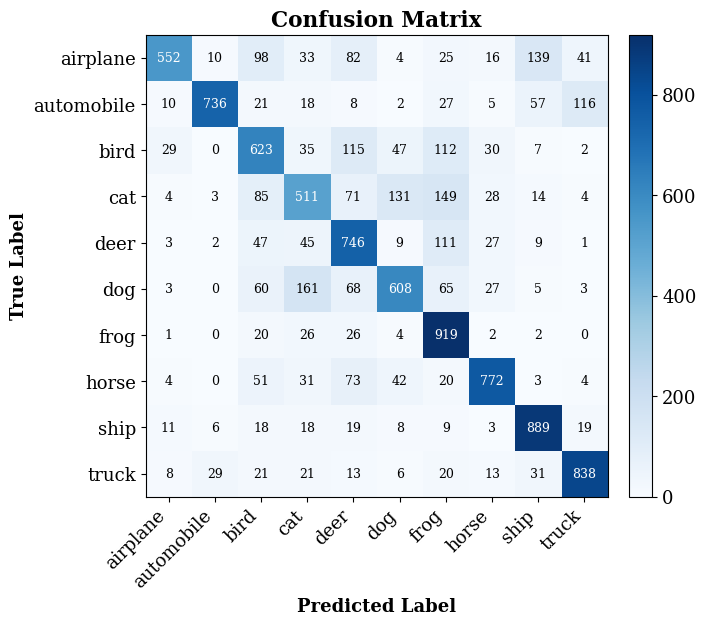

Saved: outputs/figures/11_confusion_matrix.png


In [40]:
y_pred_probs = cnn_model.predict(x_test_n, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test.flatten()

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average="macro")
rec = recall_score(y_true, y_pred, average="macro")
f1 = f1_score(y_true, y_pred, average="macro")

print(f"Test Accuracy : {acc:.4f}")
print(f"Precision (macro): {prec:.4f}")
print(f"Recall (macro)   : {rec:.4f}")
print(f"F1-score (macro) : {f1:.4f}")
print()
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel("Predicted Label", fontweight="bold")
ax.set_ylabel("True Label", fontweight="bold")
ax.set_title("Confusion Matrix")
for i in range(10):
    for j in range(10):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=9)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.show()
save_fig(fig, "11_confusion_matrix.png")

## Mandatory Plots : Training Accuracy, Validation Accuracy, Training Loss, Validation Loss

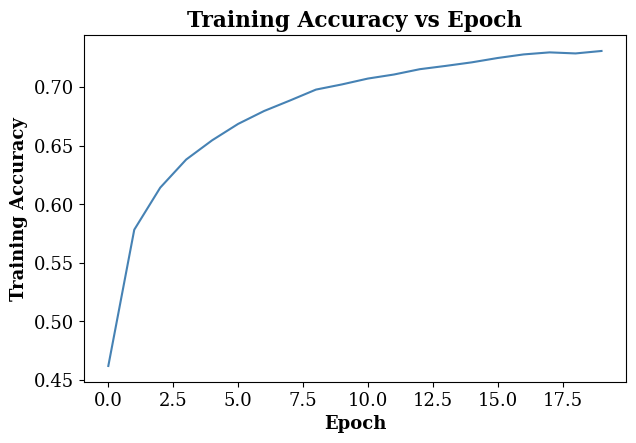

Saved: outputs/figures/07_training_accuracy.png


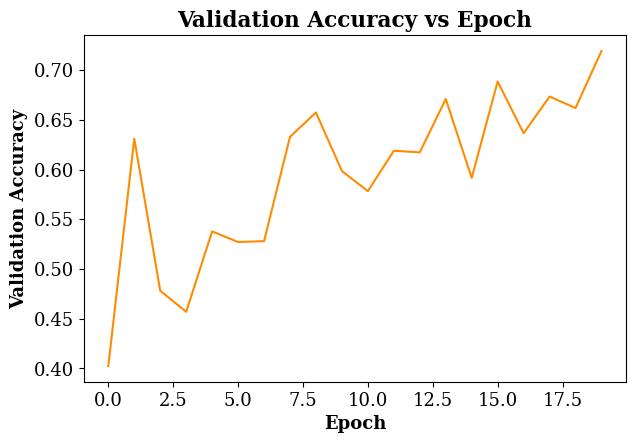

Saved: outputs/figures/08_validation_accuracy.png


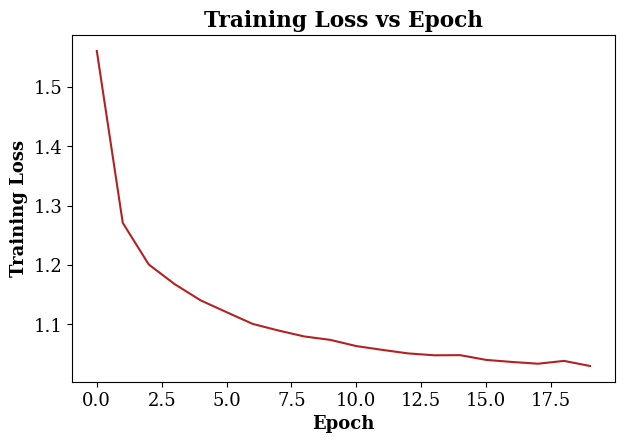

Saved: outputs/figures/09_training_loss.png


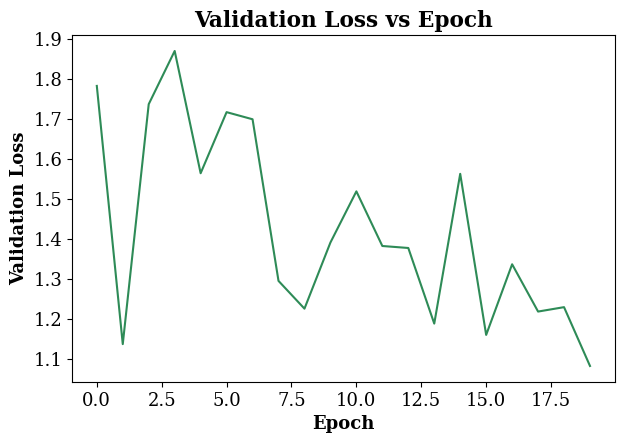

Saved: outputs/figures/10_validation_loss.png


In [41]:
# Training Accuracy
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(history.history["accuracy"], color="steelblue")
ax.set_xlabel("Epoch", fontweight="bold")
ax.set_ylabel("Training Accuracy", fontweight="bold")
ax.set_title("Training Accuracy vs Epoch")
plt.show()
save_fig(fig, "07_training_accuracy.png")

# Validation Accuracy
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(history.history["val_accuracy"], color="darkorange")
ax.set_xlabel("Epoch", fontweight="bold")
ax.set_ylabel("Validation Accuracy", fontweight="bold")
ax.set_title("Validation Accuracy vs Epoch")
plt.show()
save_fig(fig, "08_validation_accuracy.png")

# Training Loss
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(history.history["loss"], color="firebrick")
ax.set_xlabel("Epoch", fontweight="bold")
ax.set_ylabel("Training Loss", fontweight="bold")
ax.set_title("Training Loss vs Epoch")
plt.show()
save_fig(fig, "09_training_loss.png")

# Validation Loss
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(history.history["val_loss"], color="seagreen")
ax.set_xlabel("Epoch", fontweight="bold")
ax.set_ylabel("Validation Loss", fontweight="bold")
ax.set_title("Validation Loss vs Epoch")
plt.show()
save_fig(fig, "10_validation_loss.png")

## Additional Task 1 : Output Size for 64x64 Image, 5x5 Kernel, Stride 2, Padding 2

In [42]:
N, F, P, S = 64, 5, 2, 2
out_size = ((N - F + 2 * P) // S) + 1
print(f"Input Size (N)  = {N}")
print(f"Filter Size (F) = {F}")
print(f"Padding (P)     = {P}")
print(f"Stride (S)      = {S}")
print(f"Output Size     = (({N} - {F} + 2*{P}) / {S}) + 1 = {out_size}")

Input Size (N)  = 64
Filter Size (F) = 5
Padding (P)     = 2
Stride (S)      = 2
Output Size     = ((64 - 5 + 2*2) / 2) + 1 = 32


## Additional Task 2 : Trainable Parameters — 64 Filters of Size 3x3, RGB Input

In [43]:
in_channels = 3
filter_size = 3
num_filters = 64

params = (filter_size * filter_size * in_channels + 1) * num_filters
print(f"Filter size        : {filter_size}x{filter_size}")
print(f"Input channels     : {in_channels}")
print(f"Number of filters  : {num_filters}")
print(f"Trainable Parameters = ({filter_size}*{filter_size}*{in_channels} + 1) * {num_filters} = {params}")

Filter size        : 3x3
Input channels     : 3
Number of filters  : 64
Trainable Parameters = (3*3*3 + 1) * 64 = 1792


## Additional Task 3 : Compare ReLU and Sigmoid Activation Functions

Activation=relu | Final val_accuracy=0.6578
Activation=sigmoid | Final val_accuracy=0.5289


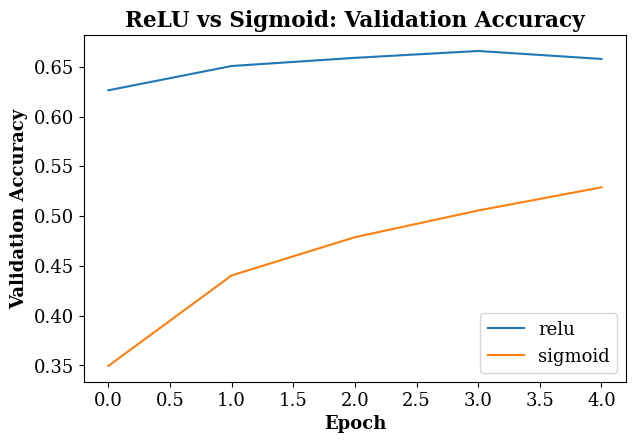

Saved: outputs/figures/12_relu_vs_sigmoid.png


In [44]:
def build_cnn_activation(activation="relu"):
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(32, (3, 3), padding="same", activation=activation),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), padding="same", activation=activation),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation=activation),
        layers.Dense(10, activation="softmax")
    ])
    return model

activations = ["relu", "sigmoid"]
act_histories = {}

for act in activations:
    m = build_cnn_activation(act)
    m.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    h = m.fit(x_train_n, y_train_cat, validation_data=(x_test_n, y_test_cat),
              epochs=5, batch_size=32, verbose=0)
    act_histories[act] = h
    print(f"Activation={act} | Final val_accuracy={h.history['val_accuracy'][-1]:.4f}")

fig, ax = plt.subplots(figsize=(7, 4.5))
for act, h in act_histories.items():
    ax.plot(h.history["val_accuracy"], label=act)
ax.set_xlabel("Epoch", fontweight="bold")
ax.set_ylabel("Validation Accuracy", fontweight="bold")
ax.set_title("ReLU vs Sigmoid: Validation Accuracy")
ax.legend()
plt.show()
save_fig(fig, "12_relu_vs_sigmoid.png")

## Additional Task 4 : Replace Max Pooling with Average Pooling and Compare

Max Pooling Test Accuracy : 0.7194
Avg Pooling Test Accuracy : 0.5817


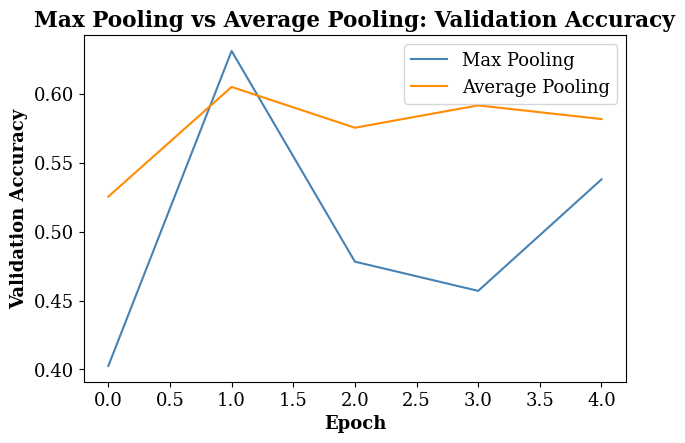

Saved: outputs/figures/13_maxpool_vs_avgpool_training.png


In [45]:
avg_cnn_model = build_cnn(pooling="avg")
avg_cnn_model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
avg_history = avg_cnn_model.fit(
    x_train_n, y_train_cat,
    validation_data=(x_test_n, y_test_cat),
    epochs=5, batch_size=32, verbose=0
)

print(f"Max Pooling Test Accuracy : {history.history['val_accuracy'][-1]:.4f}")
print(f"Avg Pooling Test Accuracy : {avg_history.history['val_accuracy'][-1]:.4f}")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(history.history["val_accuracy"][:5], label="Max Pooling", color="steelblue")
ax.plot(avg_history.history["val_accuracy"], label="Average Pooling", color="darkorange")
ax.set_xlabel("Epoch", fontweight="bold")
ax.set_ylabel("Validation Accuracy", fontweight="bold")
ax.set_title("Max Pooling vs Average Pooling: Validation Accuracy")
ax.legend()
plt.show()
save_fig(fig, "13_maxpool_vs_avgpool_training.png")

## Additional Task 5 : Increase Convolution Filters from 16 to 64 — Effect on Accuracy and Computation Time

Filters 16->32 | val_accuracy=0.6740 | time=34.43s
Filters 64->128 | val_accuracy=0.6766 | time=52.51s


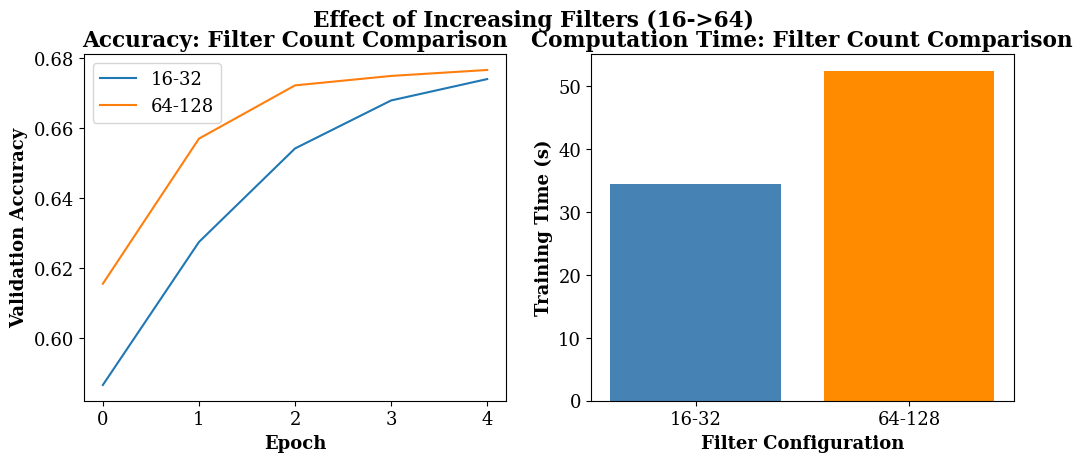

Saved: outputs/figures/14_filter_count_comparison.png


In [46]:
import time

def build_cnn_filters(f1=16, f2=32):
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(f1, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(f2, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dense(10, activation="softmax")
    ])
    return model

filter_configs = [(16, 32), (64, 128)]
filter_results = {}

for f1, f2 in filter_configs:
    m = build_cnn_filters(f1, f2)
    m.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    start = time.time()
    h = m.fit(x_train_n, y_train_cat, validation_data=(x_test_n, y_test_cat),
              epochs=5, batch_size=32, verbose=0)
    elapsed = time.time() - start
    filter_results[f"{f1}-{f2}"] = {"history": h, "time": elapsed}
    print(f"Filters {f1}->{f2} | val_accuracy={h.history['val_accuracy'][-1]:.4f} | time={elapsed:.2f}s")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for label, res in filter_results.items():
    axes[0].plot(res["history"].history["val_accuracy"], label=label)
axes[0].set_xlabel("Epoch", fontweight="bold")
axes[0].set_ylabel("Validation Accuracy", fontweight="bold")
axes[0].set_title("Accuracy: Filter Count Comparison")
axes[0].legend()

labels = list(filter_results.keys())
times = [filter_results[l]["time"] for l in labels]
axes[1].bar(labels, times, color=["steelblue", "darkorange"])
axes[1].set_xlabel("Filter Configuration", fontweight="bold")
axes[1].set_ylabel("Training Time (s)", fontweight="bold")
axes[1].set_title("Computation Time: Filter Count Comparison")

fig.suptitle("Effect of Increasing Filters (16->64)", fontweight="bold")
plt.show()
save_fig(fig, "14_filter_count_comparison.png")